In [1]:
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib.ticker import LogLocator, MaxNLocator, NullLocator, FixedLocator
import csv

from common import make_canvas

In [10]:
d = 10000
dstop = 1000
k = 5
train_size = 100_000
test_size = train_size
train_noise = 0.2
tol = 1e-12
epochs = 300
batch_size = 512

algo_name = "SGD"
lr = 1e-3

plot_every = 50 if algo_name == "SGD" else 5

filename = f'LTH/harm_{algo_name}_d{d}_dstop{dstop}_k{k}_noise{train_noise}_bs{batch_size}_lr{lr}'
with open(filename+'.csv', 'rt') as csvfile:
    data = np.genfromtxt(csvfile, delimiter=',', names=True)

epoch_range = data["epoch"].astype(np.int64)[::plot_every]
train_loss_orig = data["train_loss_orig"].astype(np.float64)[::plot_every]
test_loss_orig = data["test_loss_orig"].astype(np.float64)[::plot_every]
train_loss_cp = data["train_loss_cp"].astype(np.float64)[::plot_every]
test_loss_cp = data["test_loss_cp"].astype(np.float64)[::plot_every]
train_loss_naive = data["train_loss_naive"].astype(np.float64)[::plot_every]
test_loss_naive = data["test_loss_naive"].astype(np.float64)[::plot_every]

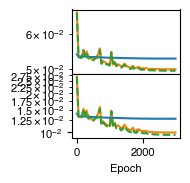

In [11]:
fig, axs = make_canvas(rows=2, cols=1, axes_width_pt=80, axes_aspect=1, sharex=True, gridspec_kw={'hspace': 0})

axs[0].plot(epoch_range, train_loss_cp, color='tab:orange',marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[0].plot(epoch_range, train_loss_naive, color='tab:blue',  marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[0].plot(epoch_range, train_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
axs[0].set_yscale('log')
# axs[0].yaxis.set_major_locator(LogLocator(base=10.0, numticks=6))
# axs[0].yaxis.set_minor_locator(NullLocator()) 
# axs[0].set_ylabel('Train loss')
# axs[0].legend()

# Plot Test Loss vs. epoch
axs[1].plot(epoch_range, test_loss_cp, color='tab:orange', marker=None, markersize=2, label=f'Compressed d\'={dstop}')
axs[1].plot(epoch_range, test_loss_naive, color='tab:blue', marker=None, markersize=2, label=f'Naive d\'={dstop}')
axs[1].plot(epoch_range, test_loss_orig,  color='tab:green', marker=None, markersize=2, ls='--', label=f'Original d={d}')
# axs[1].set_ylabel('Test loss')
axs[1].set_xlabel('Epoch')
axs[1].set_yscale('log')
# axs[1].yaxis.set_major_locator(NullLocator())

plt.tight_layout()
plt.savefig('out.pdf', format='pdf', bbox_inches='tight', pad_inches=0)
plt.show()

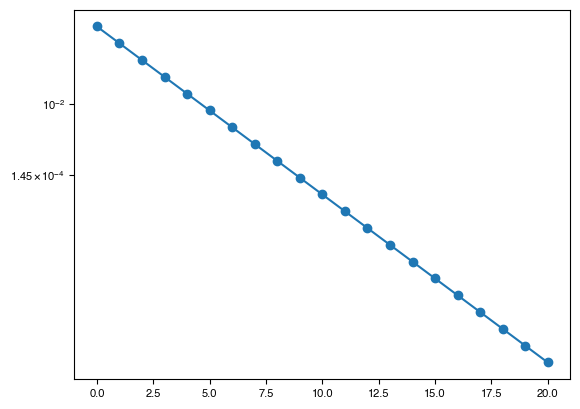

In [37]:
x = np.linspace(0, 20, 21)
y = np.exp(-x)


fig, ax = plt.subplots()

ax.plot(x, y, marker = 'o')

ax.set_yscale('log')
ax.yaxis.set_major_locator(FixedLocator(locs = [0.01, 0.000145]))

fig.canvas.draw()

# yticks = ax.yaxis.get_major_ticks()
# for tick in yticks:
#     if np.log10(tick.get_loc())%3 != 0:
#         tick.label1.set_visible(False)

plt.show()